# Regional numerical-to-population variability ratio

## Figure 4 and supplementary PD/HC extensions

This notebook generates the paper's regional NPVR brain maps for:

- **Figure 4:** the combined Parkinson's disease and healthy-control population (`PD+HC`);
- **Supplementary figure:** Parkinson's disease (`PD`); and
- **Supplementary figure:** healthy controls (`HC`).

The visual specification from the paper is preserved: a 4 × 2 layout, thresholds 0.1 and 0.4, orthogonal Schaefer-atlas views, panel-wise normalization to $[0,1]$, the `Reds` color map, SD annotations, and a shared variability-ratio colorbar.

## Reproducibility and data layout

Python 3.11+ dependencies:

```bash
python -m pip install "numpy>=2" "pandas>=2" "matplotlib>=3.7" "nilearn>=0.10"
```

Set `FMRI_DATA_ROOT` to `Allpop/Absolute_thresholding/MCA`, which contains the `table_corr*` folders. This location is discovered automatically in the current project layout. The PD, HC, and combined estimates are all calculated from the pickle batches in these folders. Nilearn downloads the 100-region, seven-network Schaefer atlas on first use if it is not already cached.

The plotting code saves PDF, PNG, and 300-dpi LZW-compressed TIFF files directly in `Fig4-RegionalVariability/`.

In [1]:
from __future__ import annotations

import importlib
import json
import os
from pathlib import Path
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from nilearn import datasets, image, plotting
import pandas as pd

# Pickles written by NumPy 2 use numpy._core; alias it for NumPy 1.x kernels.
if not hasattr(np, "_core"):
    sys.modules.setdefault("numpy._core", np.core)
    for module_name in (
        "numeric", "multiarray", "numerictypes", "umath",
        "fromnumeric", "_multiarray_umath",
    ):
        sys.modules.setdefault(
            f"numpy._core.{module_name}",
            importlib.import_module(f"numpy.core.{module_name}"),
        )


THRESHOLDS = (0.05, 0.1, 0.2, 0.3, 0.4, 0.5)
BATCHES = (1, 2, 3, 4, 5)
SESSION = "1"
ACQUISITION = "acq-RL"
EXCLUDED_ACQUISITIONS = {"acq-RLsplit1", "acq-LRsplit1"}

LOCAL_METRICS = {
    "degree": ("degree_centralities", "Degree centrality"),
    "betweenness": ("betweenness_centralities", "Betweenness centrality"),
    "eigenvector": ("eigenvector_centralities", "Eigenvector centrality"),
    "clustering": ("clustering_coefficients", "Clustering coefficient"),
}
GLOBAL_METRICS = {
    "small_worldness": ("small_worldness", "Small-worldness"),
    "average_shortest_path_length": (
        "avg_shortest_path_length",
        "Average shortest path length",
    ),
}
METRICS = {**LOCAL_METRICS, **GLOBAL_METRICS}

def load_subject_exclusions(
    repository_root: Path | None = None,
) -> tuple[set[str], set[str]]:
    """Load restricted QC exclusions from a local, ignored JSON file."""
    configured = os.environ.get("PPMI_SUBJECT_EXCLUSIONS_FILE")
    candidates = []
    if configured:
        candidates.append(Path(configured).expanduser())
    candidates.extend(
        candidate / "data" / "subject_exclusions.json"
        for candidate in (Path.cwd(), *Path.cwd().parents)
    )
    if repository_root is not None:
        candidates.insert(0, repository_root / "data" / "subject_exclusions.json")

    for candidate in candidates:
        if candidate.is_file():
            payload = json.loads(candidate.read_text(encoding="utf-8"))
            return set(payload.get("pd", [])), set(payload.get("hc", []))

    raise FileNotFoundError(
        "Set PPMI_SUBJECT_EXCLUSIONS_FILE or create the ignored local file "
        "data/subject_exclusions.json with 'pd' and 'hc' arrays."
    )


def find_repository_root(start: Path | None = None) -> Path:
    """Locate the numerical-variability project from any launch directory."""
    start = (start or Path.cwd()).resolve()
    nested = Path(
        "overlap/allbatches/Allpop/pickles/"
        "Numerical-Variability-of-functional-MRI-Graph-Measures"
    )
    for base in (start, *start.parents):
        for candidate in (base, base / nested):
            if (candidate / "Fig4-RegionalVariability/Fig4-RegionalVariability.ipynb").is_file():
                return candidate
    raise FileNotFoundError("Could not locate the numerical-variability project.")


def has_threshold_data(candidate: Path) -> bool:
    return any(
        (candidate / folder).is_dir()
        for folder in ("table_corr0.05", "table_correther0.05")
    )


def find_data_root(repository_root: Path) -> Path:
    """Resolve the MCA directory containing the threshold folders."""
    if configured := os.environ.get("FMRI_DATA_ROOT"):
        candidate = Path(configured).expanduser().resolve()
        if not candidate.is_dir():
            raise FileNotFoundError(f"FMRI_DATA_ROOT does not exist: {candidate}")
        if not has_threshold_data(candidate):
            raise FileNotFoundError(f"No table_corr* folders in {candidate}")
        return candidate

    candidates = []
    for base in (repository_root, *repository_root.parents):
        candidates.extend([
            base,
            base / "Absolute_thresholding/MCA",
            base / "overlap/allbatches/Allpop/Absolute_thresholding/MCA",
        ])
    for candidate in candidates:
        if has_threshold_data(candidate):
            return candidate

    raise FileNotFoundError(
        "Could not locate table_corr0.05. Set FMRI_DATA_ROOT to the MCA directory."
    )


REPOSITORY_ROOT = find_repository_root()
PD_SUBJECTS_TO_REMOVE, HC_SUBJECTS_TO_REMOVE = load_subject_exclusions(
    REPOSITORY_ROOT
)
DATA_ROOT = find_data_root(REPOSITORY_ROOT)
FIGURE_DIR = REPOSITORY_ROOT / "Fig4-RegionalVariability"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository:    {REPOSITORY_ROOT}")
print(f"Data:          {DATA_ROOT}")
print(f"Figures:       {FIGURE_DIR}")

Repository:    /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures
Data:          /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/Absolute_thresholding/MCA
Figures:       /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability


## 1. Load and quality-control the graph measures

For each threshold, the five Parkinson's disease batches are concatenated and combined with the healthy-control batch. Both groups use the same `WConf` input condition. This fixes an earlier copy/paste error that duplicated the healthy-control data at thresholds 0.05–0.4 and mixed input conditions at threshold 0.5.

In [2]:
def threshold_directory(threshold: float) -> Path:
    for prefix in ("table_corr", "table_correther"):
        directory = DATA_ROOT / f"{prefix}{threshold}"
        if directory.is_dir():
            return directory
    raise FileNotFoundError(f"No data folder found for threshold {threshold}")


def read_population_data(threshold: float) -> dict[str, pd.DataFrame]:
    """Load and QC the WConf inputs for one graph-construction threshold."""
    directory = threshold_directory(threshold)
    pd_frames = [
        pd.read_pickle(directory / f"Result_tableWConf_batch_{batch}.pkl")
        for batch in BATCHES
    ]
    pd_data = pd.concat(pd_frames, ignore_index=True)
    hc_data = pd.read_pickle(directory / "Result_tableWConf_batch_hc.pkl")

    pd_data = pd_data.loc[~pd_data["subject"].isin(PD_SUBJECTS_TO_REMOVE)].copy()
    hc_data = hc_data.loc[~hc_data["subject"].isin(HC_SUBJECTS_TO_REMOVE)].copy()
    combined = pd.concat([pd_data, hc_data], ignore_index=True)

    return {"pd": pd_data, "hc": hc_data, "combined": combined}


population_data = {
    threshold: read_population_data(threshold) for threshold in THRESHOLDS
}

sample_sizes = pd.DataFrame(
    {
        "threshold": threshold,
        "PD": frames["pd"]["subject"].nunique(),
        "HC": frames["hc"]["subject"].nunique(),
        "combined": frames["combined"]["subject"].nunique(),
    }
    for threshold, frames in population_data.items()
).set_index("threshold")
sample_sizes

,PD,HC,combined
threshold,,,
0.05,218,36,254
0.10,218,36,254
0.20,216,36,252
0.30,212,36,248
0.40,206,36,242
0.50,183,32,215


## 2. Estimate numerical and population variability

Let $X_{s,r,m,k}$ denote graph metric $m$ for subject $s$, region $r$, and MCA repetition $k$.

Numerical variability is first estimated within each subject:

$$
V^{\mathrm{num}}_{s,r,m} = \operatorname{Var}_{k}(X_{s,r,m,k}),
\qquad
\sigma^{\mathrm{num}}_{r,m} =
\sqrt{\operatorname{mean}_{s}\!\left(V^{\mathrm{num}}_{s,r,m}\right)}.
$$

Population variability is estimated across subjects within each repetition:

$$
V^{\mathrm{pop}}_{k,r,m} = \operatorname{Var}_{s}(X_{s,r,m,k}),
\qquad
\sigma^{\mathrm{pop}}_{r,m} =
\sqrt{\operatorname{mean}_{k}\!\left(V^{\mathrm{pop}}_{k,r,m}\right)}.
$$

Local metrics yield one value per atlas region; global metrics yield one scalar value.

In [3]:
def metric_values(group: pd.DataFrame, source_column: str) -> np.ndarray:
    """Convert a graph-metric column to a numeric observation array."""
    values = []
    for value in group[source_column]:
        if isinstance(value, dict):
            value = list(value.values())
        values.append(np.asarray(value, dtype=float))
    return np.asarray(values, dtype=float)


def calculate_group_variances(
    data: pd.DataFrame,
    group_columns: list[str],
    *,
    unique_subjects: bool = False,
    minimum_observations: int = 1,
) -> pd.DataFrame:
    """Calculate metric variances within the requested grouping dimensions."""
    filtered = data.loc[~data["acquisition"].isin(EXCLUDED_ACQUISITIONS)].copy()
    rows = []

    for keys, group in filtered.groupby(group_columns, sort=True):
        if unique_subjects:
            group = group.drop_duplicates("subject")
        if len(group) < minimum_observations:
            continue

        keys = keys if isinstance(keys, tuple) else (keys,)
        result = dict(zip(group_columns, keys))
        for metric, (source_column, _) in METRICS.items():
            result[metric] = np.var(metric_values(group, source_column), axis=0)
        rows.append(result)

    return pd.DataFrame(rows)


def estimate_variability(data: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Estimate within-subject numerical and between-subject variances."""
    numerical = calculate_group_variances(
        data,
        ["subject", "session", "acquisition"],
        minimum_observations=2,
    )
    population = calculate_group_variances(
        data,
        ["repetition", "session", "acquisition"],
        unique_subjects=True,
        minimum_observations=2,
    )
    return {"numerical": numerical, "population": population}


def root_mean_variance(variance_data: pd.DataFrame) -> dict[str, np.ndarray | float]:
    """Convert repeated variance estimates to root-mean variance."""
    selected = variance_data.loc[
        (variance_data["session"].astype(str) == SESSION)
        & (variance_data["acquisition"] == ACQUISITION)
    ]
    if selected.empty:
        raise ValueError(f"No rows found for session={SESSION}, acquisition={ACQUISITION}")

    result = {}
    for metric in METRICS:
        stacked = np.stack(selected[metric].to_numpy())
        value = np.sqrt(np.mean(stacked, axis=0))
        result[metric] = float(value) if value.ndim == 0 else value
    return result

In [4]:
variance_estimates = {
    threshold: estimate_variability(frames["combined"])
    for threshold, frames in population_data.items()
}

variability = {
    threshold: {
        kind: root_mean_variance(variance_frame)
        for kind, variance_frame in estimates.items()
    }
    for threshold, estimates in variance_estimates.items()
}

print(f"Computed NV and PV at {len(variability)} thresholds.")

Computed NV and PV at 6 thresholds.


## 3. Compute NPVR

For each region and graph metric, the numerical-to-population variability ratio is

$$
\operatorname{NPVR}_{r,m} =
\frac{\sigma^{\mathrm{num}}_{r,m}}{\sigma^{\mathrm{pop}}_{r,m}}.
$$

The combined-population NPVR is computed directly from the estimates above. The PD-only and HC-only summaries are loaded from the analysis pipeline's subject-level CSV files. Those files store squared terms, so the group estimate is $\sqrt{|\operatorname{mean}(x)|}$, matching the original workflow.

In [5]:
def safe_ratio(numerator, denominator):
    """Divide elementwise and represent zero denominators as missing values."""
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.divide(
            numerator,
            denominator,
            out=np.full_like(numerator, np.nan, dtype=float),
            where=denominator != 0,
        )
    return float(ratio) if ratio.ndim == 0 else ratio


combined_npvr = {
    threshold: {
        metric: safe_ratio(
            estimates["numerical"][metric], estimates["population"][metric]
        )
        for metric in METRICS
    }
    for threshold, estimates in variability.items()
}


def calculate_group_npvr(
    threshold: float, group: str
) -> dict[str, np.ndarray | float]:
    """Calculate NPVR directly from the PD or HC source observations."""
    estimates = {
        kind: root_mean_variance(variance_frame)
        for kind, variance_frame in estimate_variability(
            population_data[threshold][group]
        ).items()
    }
    return {
        metric: safe_ratio(
            estimates["numerical"][metric], estimates["population"][metric]
        )
        for metric in METRICS
    }


group_npvr = {
    group: {
        threshold: calculate_group_npvr(threshold, group)
        for threshold in THRESHOLDS
    }
    for group in ("pd", "hc")
}

In [6]:
def regional_mean(value) -> float:
    return float(np.nanmean(np.asarray(value, dtype=float)))


summary_rows = []
for threshold in THRESHOLDS:
    for metric, (_, label) in METRICS.items():
        summary_rows.append(
            {
                "threshold": threshold,
                "metric": label,
                "NV": regional_mean(variability[threshold]["numerical"][metric]),
                "PV": regional_mean(variability[threshold]["population"][metric]),
                "NPVR combined": regional_mean(combined_npvr[threshold][metric]),
                "NPVR PD": regional_mean(group_npvr["pd"][threshold][metric]),
                "NPVR HC": regional_mean(group_npvr["hc"][threshold][metric]),
            }
        )

summary = pd.DataFrame(summary_rows)
summary.round(4)

,threshold,metric,NV,PV,NPVR combined,NPVR PD,NPVR HC
0,0.05,Degree centrality,0.0051,0.0435,0.1181,0.1174,0.1296
1,0.05,Betweenness centrality,0.0000,0.0003,0.0633,0.0627,0.0696
2,0.05,Eigenvector centrality,0.0005,0.0031,0.1691,0.1688,0.1878
3,0.05,Clustering coefficient,0.0014,0.0307,0.0472,0.0461,0.0558
4,0.05,Small-worldness,0.0007,0.0037,0.1790,0.1770,0.1961
5,0.05,Average shortest path length,0.0012,0.0326,0.0370,0.0351,0.0489
6,0.10,Degree centrality,0.0062,0.0824,0.0754,0.0751,0.0811
7,0.10,Betweenness centrality,0.0000,0.0007,0.0687,0.0693,0.0683
8,0.10,Eigenvector centrality,0.0006,0.0059,0.1099,0.1098,0.1203
9,0.10,Clustering coefficient,0.0026,0.0561,0.0456,0.0450,0.0506


## 4. Paper Figure 4 — combined PD and HC population

Each panel is normalized independently to display its regional pattern. The annotated SD is calculated from the original, unnormalized regional NPVR values.

In [7]:
# These settings, dimensions, and positions reproduce the paper's figure style.
plt.rcParams.update(
    {
        "axes.titlesize": 28,
        "axes.labelsize": 28,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 28,
        "figure.titlesize": 28,
    }
)

FIGURE_THRESHOLDS = (0.1, 0.4)
PANEL_LABELS = ("A", "B")
FIGURE_METRICS = {
    "betweenness": "Betweenness Centrality",
    "clustering": "Clustering Coefficient",
    "eigenvector": "Eigenvector Centrality",
    "degree": "Degree Centrality",
}

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
ATLAS_FILENAME = atlas.maps


def normalize_region_values(values: np.ndarray) -> np.ndarray:
    """Normalize one panel to [0, 1], as in the paper figures."""
    values = np.asarray(values, dtype=float)
    value_range = np.ptp(values)
    if value_range == 0:
        return np.zeros_like(values)
    return (values - np.min(values)) / value_range


def map_values_to_atlas(values: np.ndarray, atlas_filename: str):
    """Map 100 regional values to the Schaefer atlas parcels."""
    atlas_image = image.load_img(atlas_filename)
    atlas_data = atlas_image.get_fdata()
    mapped_data = np.zeros_like(atlas_data)

    for region, value in enumerate(np.nan_to_num(values), start=1):
        mapped_data[atlas_data == region] = value
    return image.new_img_like(atlas_image, mapped_data)


def render_brain_snapshot(values: np.ndarray, output_path: Path) -> None:
    """Render one orthogonal brain-map panel using the paper's settings."""
    plotting.plot_stat_map(
        map_values_to_atlas(normalize_region_values(values), ATLAS_FILENAME),
        display_mode="ortho",
        cut_coords=[2, 0, 0],
        cmap="Reds",
        colorbar=False,
        black_bg=False,
        dim=0,
        threshold=0,
        symmetric_cbar=False,
        vmax=1,
        output_file=str(output_path),
    )


def plot_regional_npvr(
    group_label: str,
    ratios: dict[float, dict[str, np.ndarray | float]],
) -> tuple[plt.Figure, pd.DataFrame]:
    """Create the paper-style 4 × 2 regional NPVR figure for one population."""
    snapshots: dict[str, dict[float, np.ndarray]] = {
        metric: {} for metric in FIGURE_METRICS
    }
    standard_deviations = []

    with tempfile.TemporaryDirectory() as temporary_directory:
        temporary_directory = Path(temporary_directory)
        for metric, metric_label in FIGURE_METRICS.items():
            for threshold in FIGURE_THRESHOLDS:
                values = np.asarray(ratios[threshold][metric], dtype=float)
                standard_deviations.append(
                    {
                        "Threshold": threshold,
                        "Metric": metric_label,
                        "Std": np.std(values, ddof=1),
                    }
                )
                snapshot_path = temporary_directory / f"{group_label}_{metric}_{threshold}.png"
                render_brain_snapshot(values, snapshot_path)
                snapshots[metric][threshold] = plt.imread(snapshot_path)

    sd_table = pd.DataFrame(standard_deviations)
    figure, axes = plt.subplots(
        len(FIGURE_METRICS), len(FIGURE_THRESHOLDS), figsize=(20, 15)
    )
    plt.subplots_adjust(
        wspace=0.01,
        hspace=0.05,
        left=0.08,
        right=0.90,
        bottom=0.08,
        top=0.92,
    )

    for row, (metric, metric_label) in enumerate(FIGURE_METRICS.items()):
        for column, threshold in enumerate(FIGURE_THRESHOLDS):
            axis = axes[row, column]
            axis.imshow(snapshots[metric][threshold])
            axis.axis("off")

            if row == 0:
                axis.set_title(f"Threshold = {threshold}", fontsize=28, pad=8)
                axis.text(
                    0.0,
                    1.06,
                    PANEL_LABELS[column],
                    transform=axis.transAxes,
                    fontsize=32,
                    fontweight="bold",
                    va="bottom",
                    ha="left",
                    clip_on=False,
                )
            if column == 0:
                axis.text(
                    -0.15,
                    0.5,
                    metric_label,
                    transform=axis.transAxes,
                    fontsize=28,
                    va="center",
                    ha="right",
                    weight="bold",
                )

            sd_value = sd_table.loc[
                (sd_table["Threshold"] == threshold)
                & (sd_table["Metric"] == metric_label),
                "Std",
            ].iloc[0]
            axis.text(
                0.5,
                0.95,
                f"SD = {sd_value:.3f}",
                transform=axis.transAxes,
                ha="center",
                va="top",
                fontsize=24,
                color="black",
            )

    colorbar_axis = figure.add_axes([0.93, 0.15, 0.02, 0.7])
    colorbar = figure.colorbar(
        plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=1)),
        cax=colorbar_axis,
    )
    colorbar.set_label("Variability Ratio", rotation=270, labelpad=30)
    return figure, sd_table


def save_regional_figure(figure: plt.Figure, filename_stem: str) -> None:
    """Save PDF, PNG preview, and 300-dpi LZW-compressed TIFF."""
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"
    figure.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
    figure.savefig(
        FIGURE_DIR / f"{filename_stem}.png",
        format="png",
        bbox_inches="tight",
        dpi=180,
    )
    tif_path = FIGURE_DIR / f"{filename_stem}.tif"
    figure.savefig(
        tif_path, format="tiff", bbox_inches="tight", dpi=300,
        pil_kwargs={"compression": "tiff_lzw"},
    )
    print(f"Generated PDF: {pdf_path}")
    print(f"Generated TIFF: {tif_path}")

[fetch_atlas_schaefer_2018] Dataset found in /home/ubuntu/nilearn_data/schaefer_2018


Generated PDF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-PD+HC.pdf
Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-PD+HC.tif


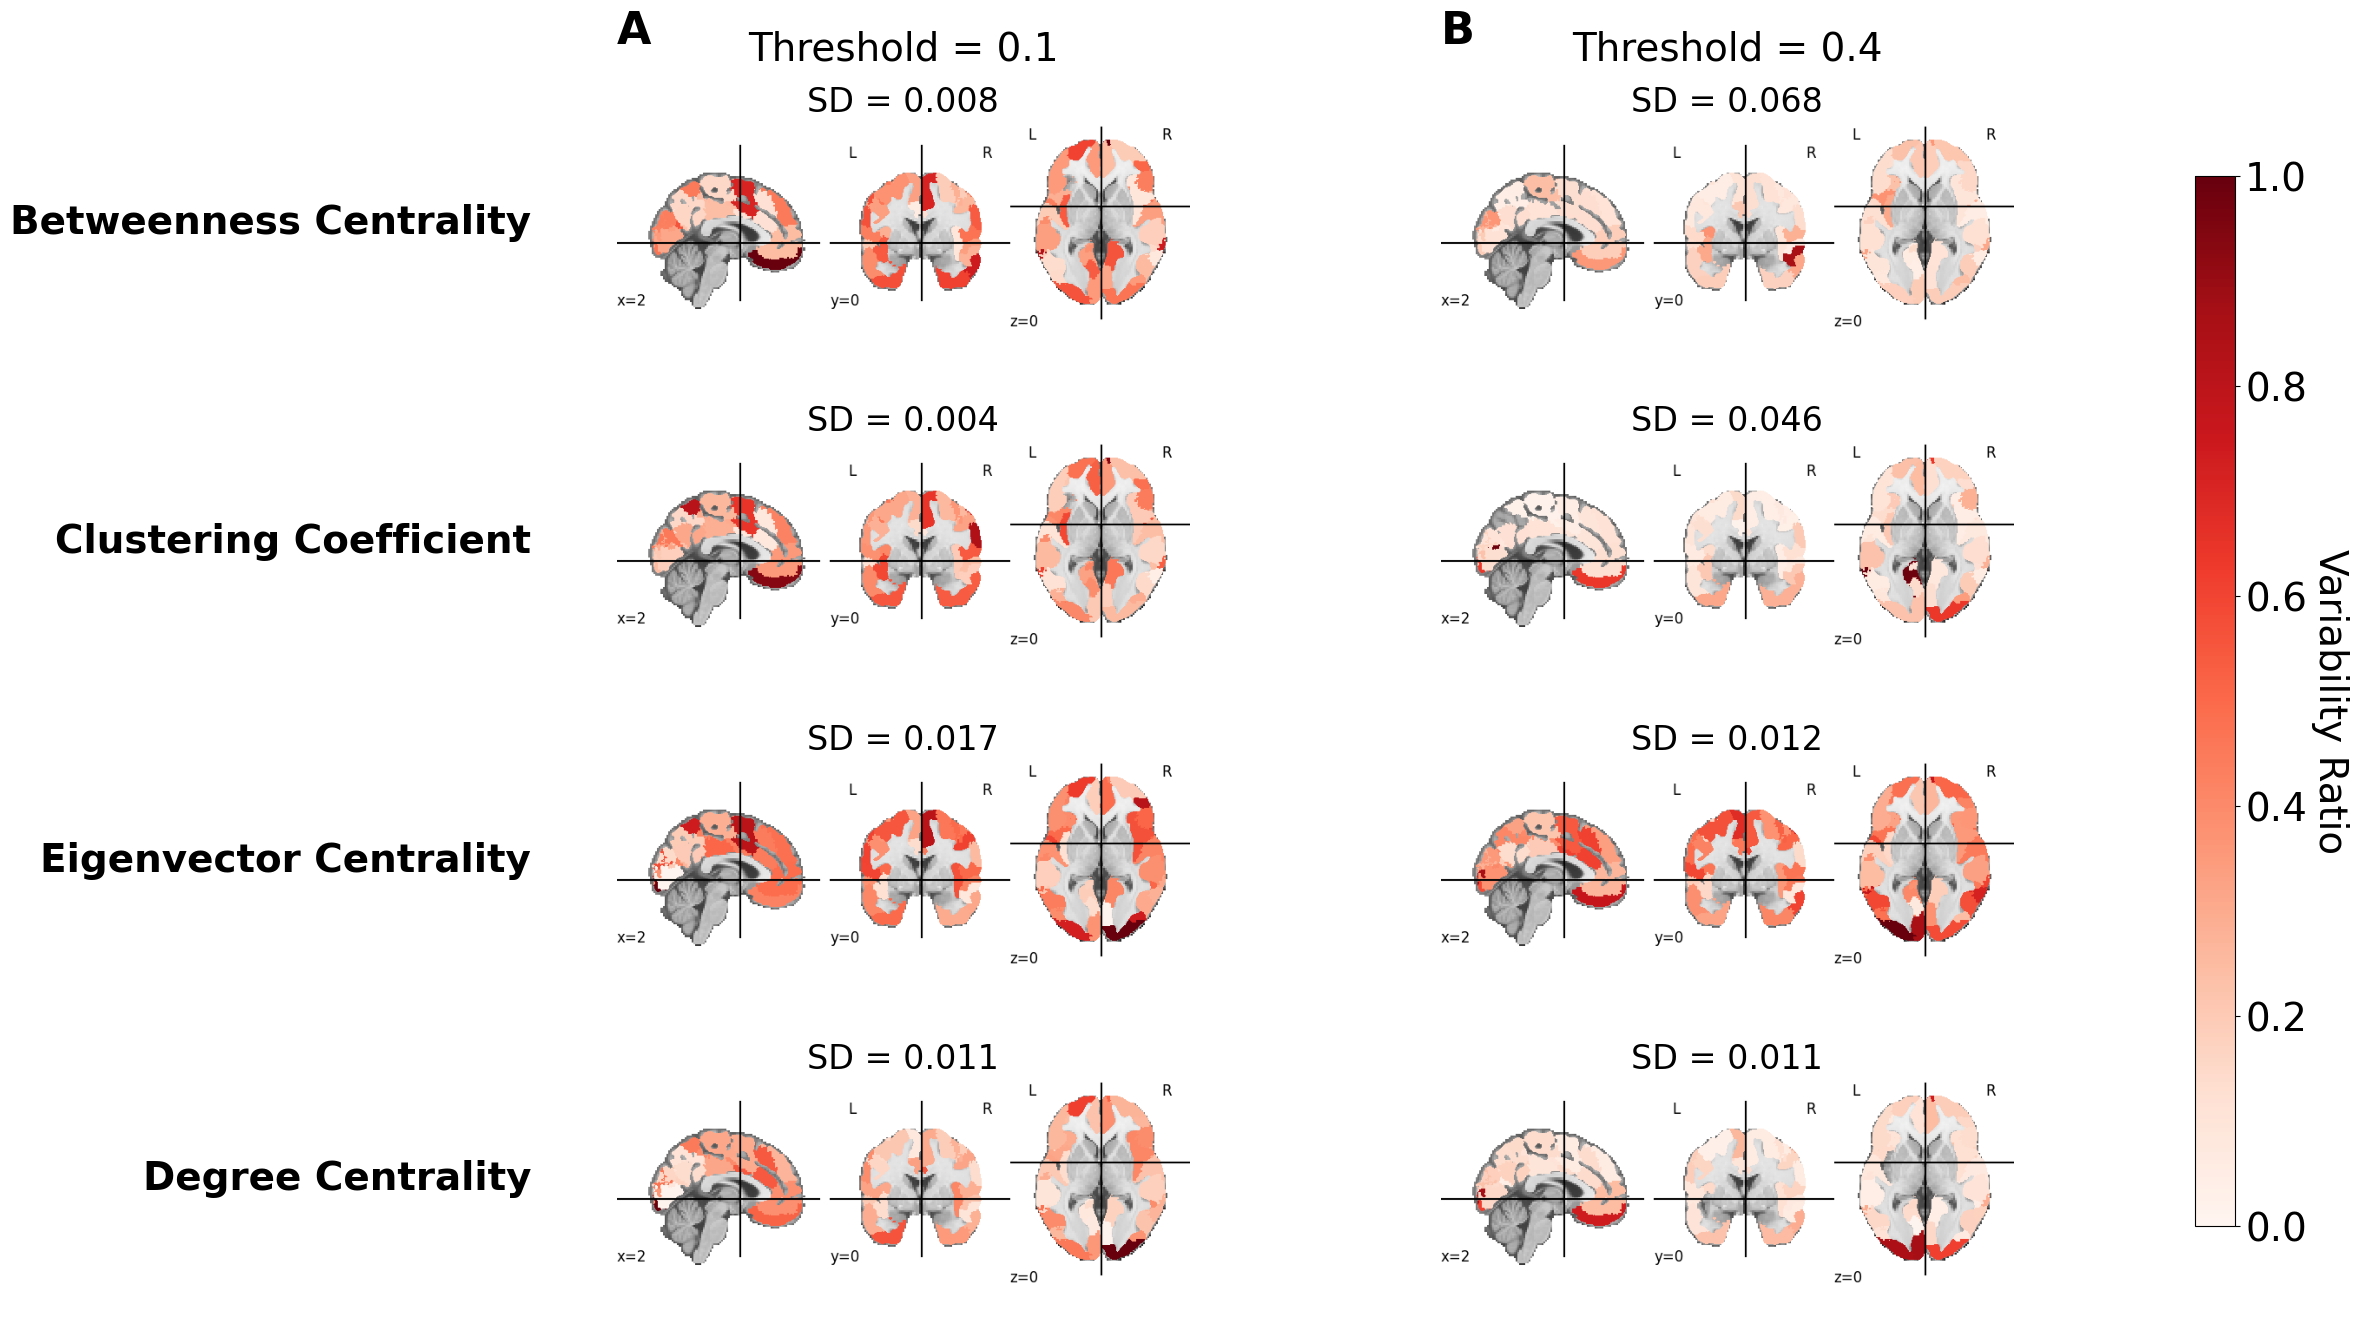

,Threshold,Metric,Std
0,0.1,Betweenness Centrality,0.008166
1,0.4,Betweenness Centrality,0.067744
2,0.1,Clustering Coefficient,0.004456
3,0.4,Clustering Coefficient,0.045997
4,0.1,Eigenvector Centrality,0.016681
5,0.4,Eigenvector Centrality,0.011550
6,0.1,Degree Centrality,0.010607
7,0.4,Degree Centrality,0.010672


In [8]:
figure4, figure4_sd = plot_regional_npvr("PD+HC", combined_npvr)
save_regional_figure(figure4, "fig4-PD+HC")
plt.show()

figure4_sd

![Figure 4: regional NPVR for the combined PD and HC population](Figures/fig4-PD+HC.png)

## 5. Supplementary figures — PD and HC separately

The supplementary figures use the identical layout, normalization, annotations, dimensions, and color scale as Figure 4.

Generated PDF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-PD.pdf
Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-PD.tif


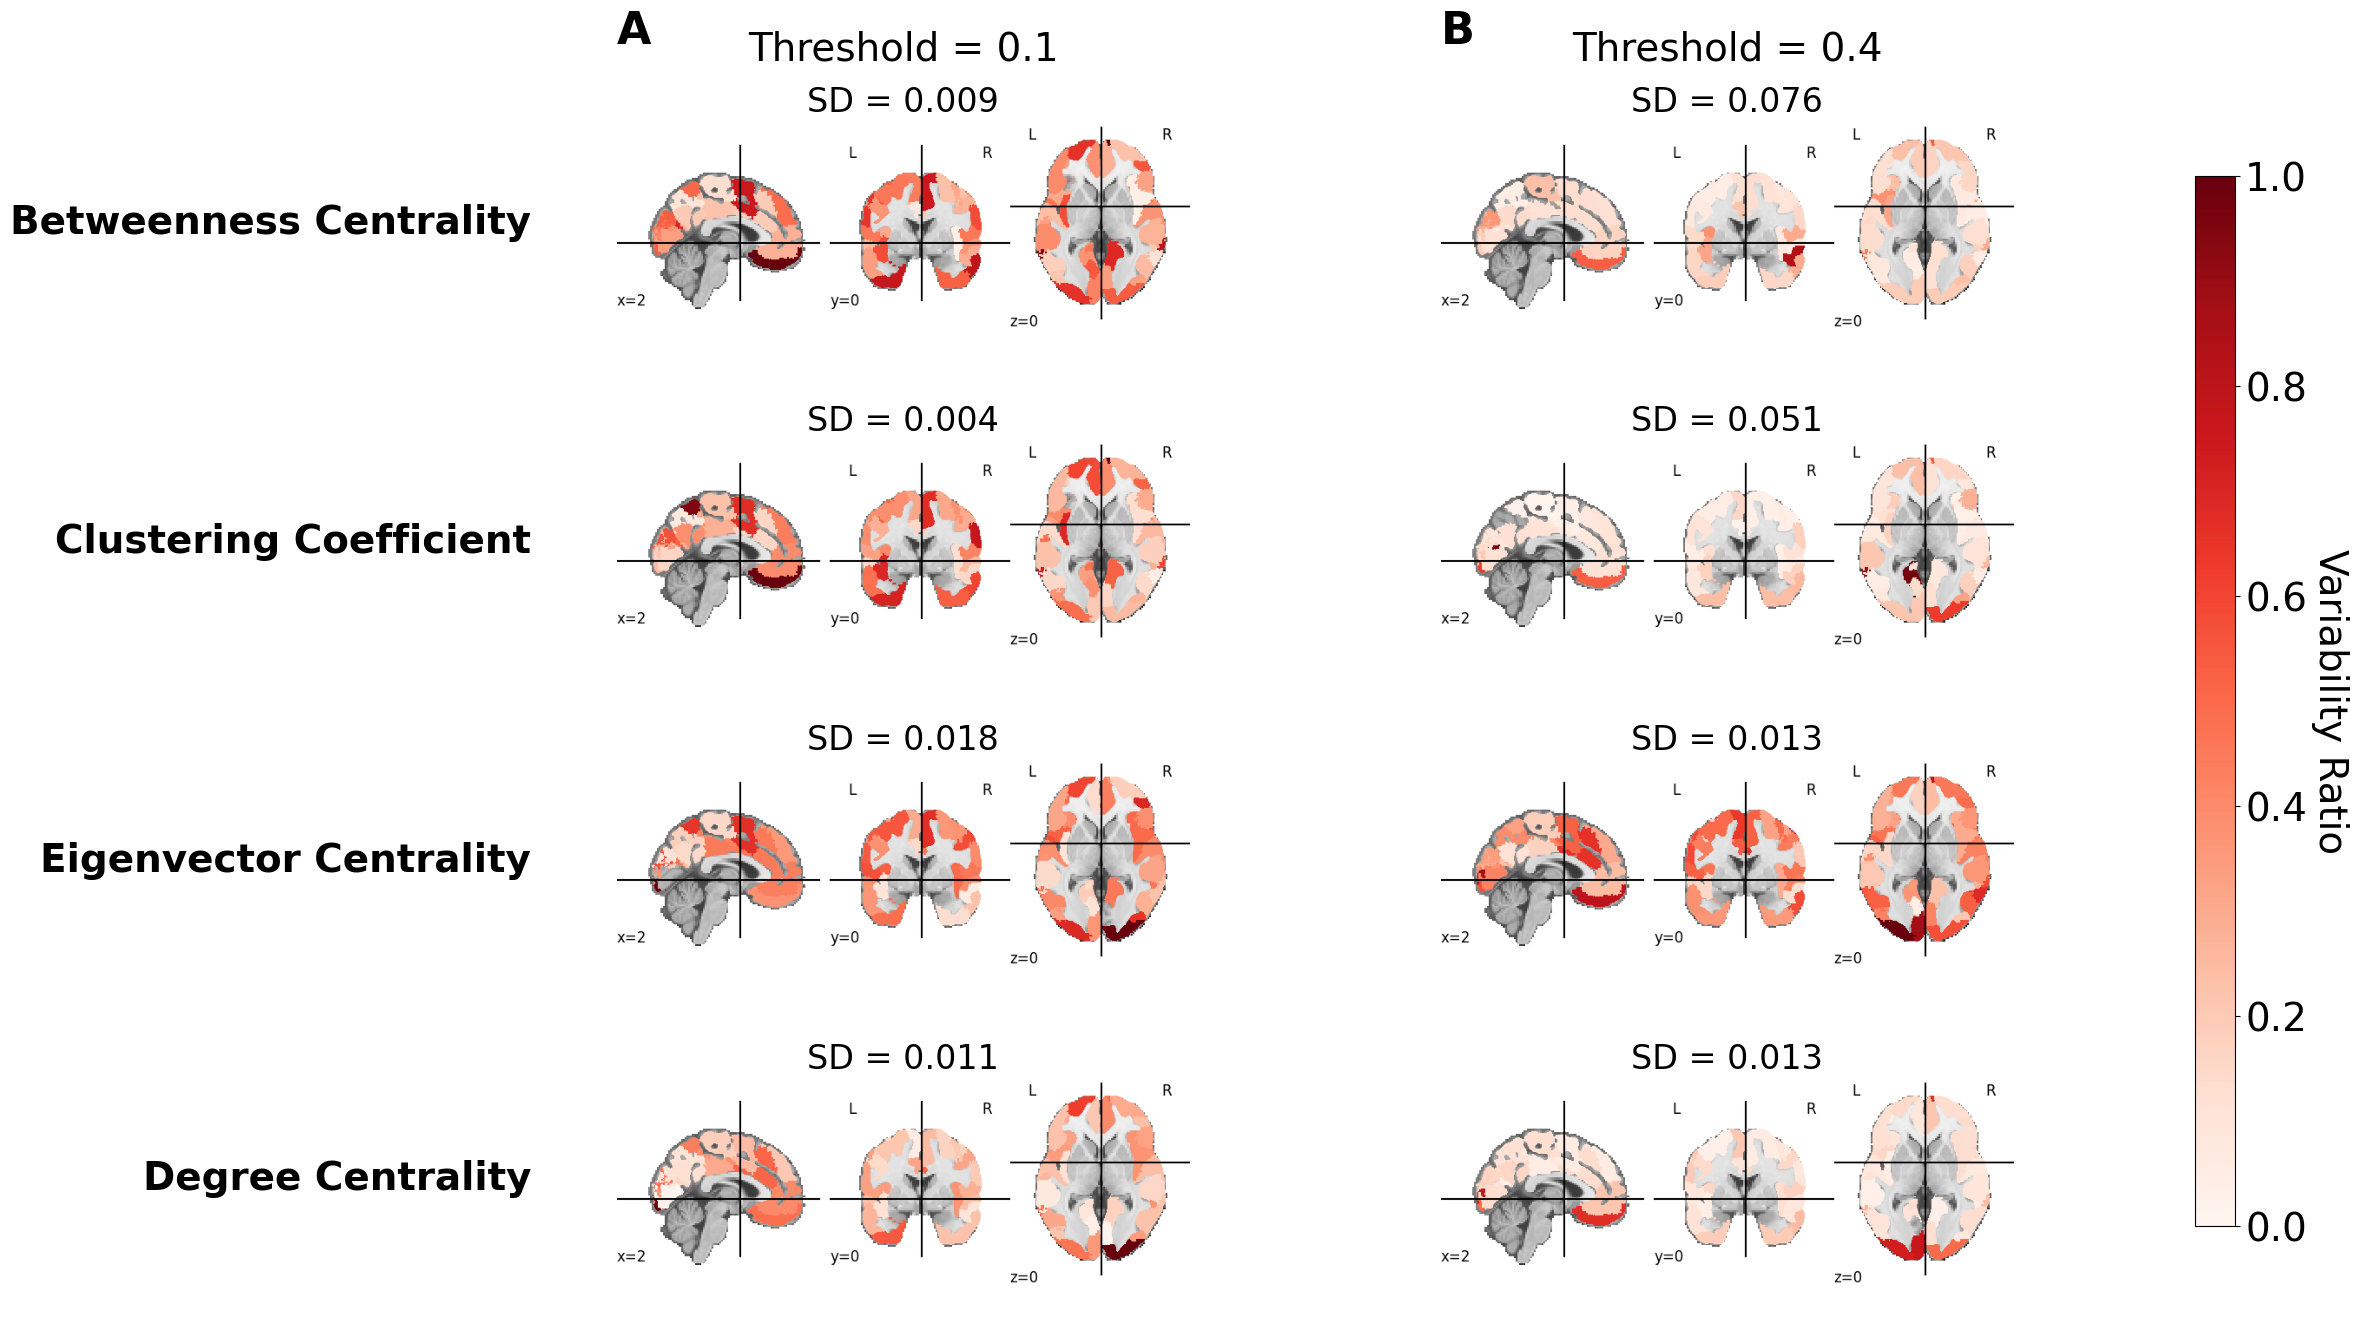

Generated PDF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-HC.pdf
Generated TIFF: /home/ubuntu/Desktop/Thesis/overlap/allbatches/Allpop/pickles/Numerical-Variability-of-functional-MRI-Graph-Measures/Fig4-RegionalVariability/fig4-HC.tif


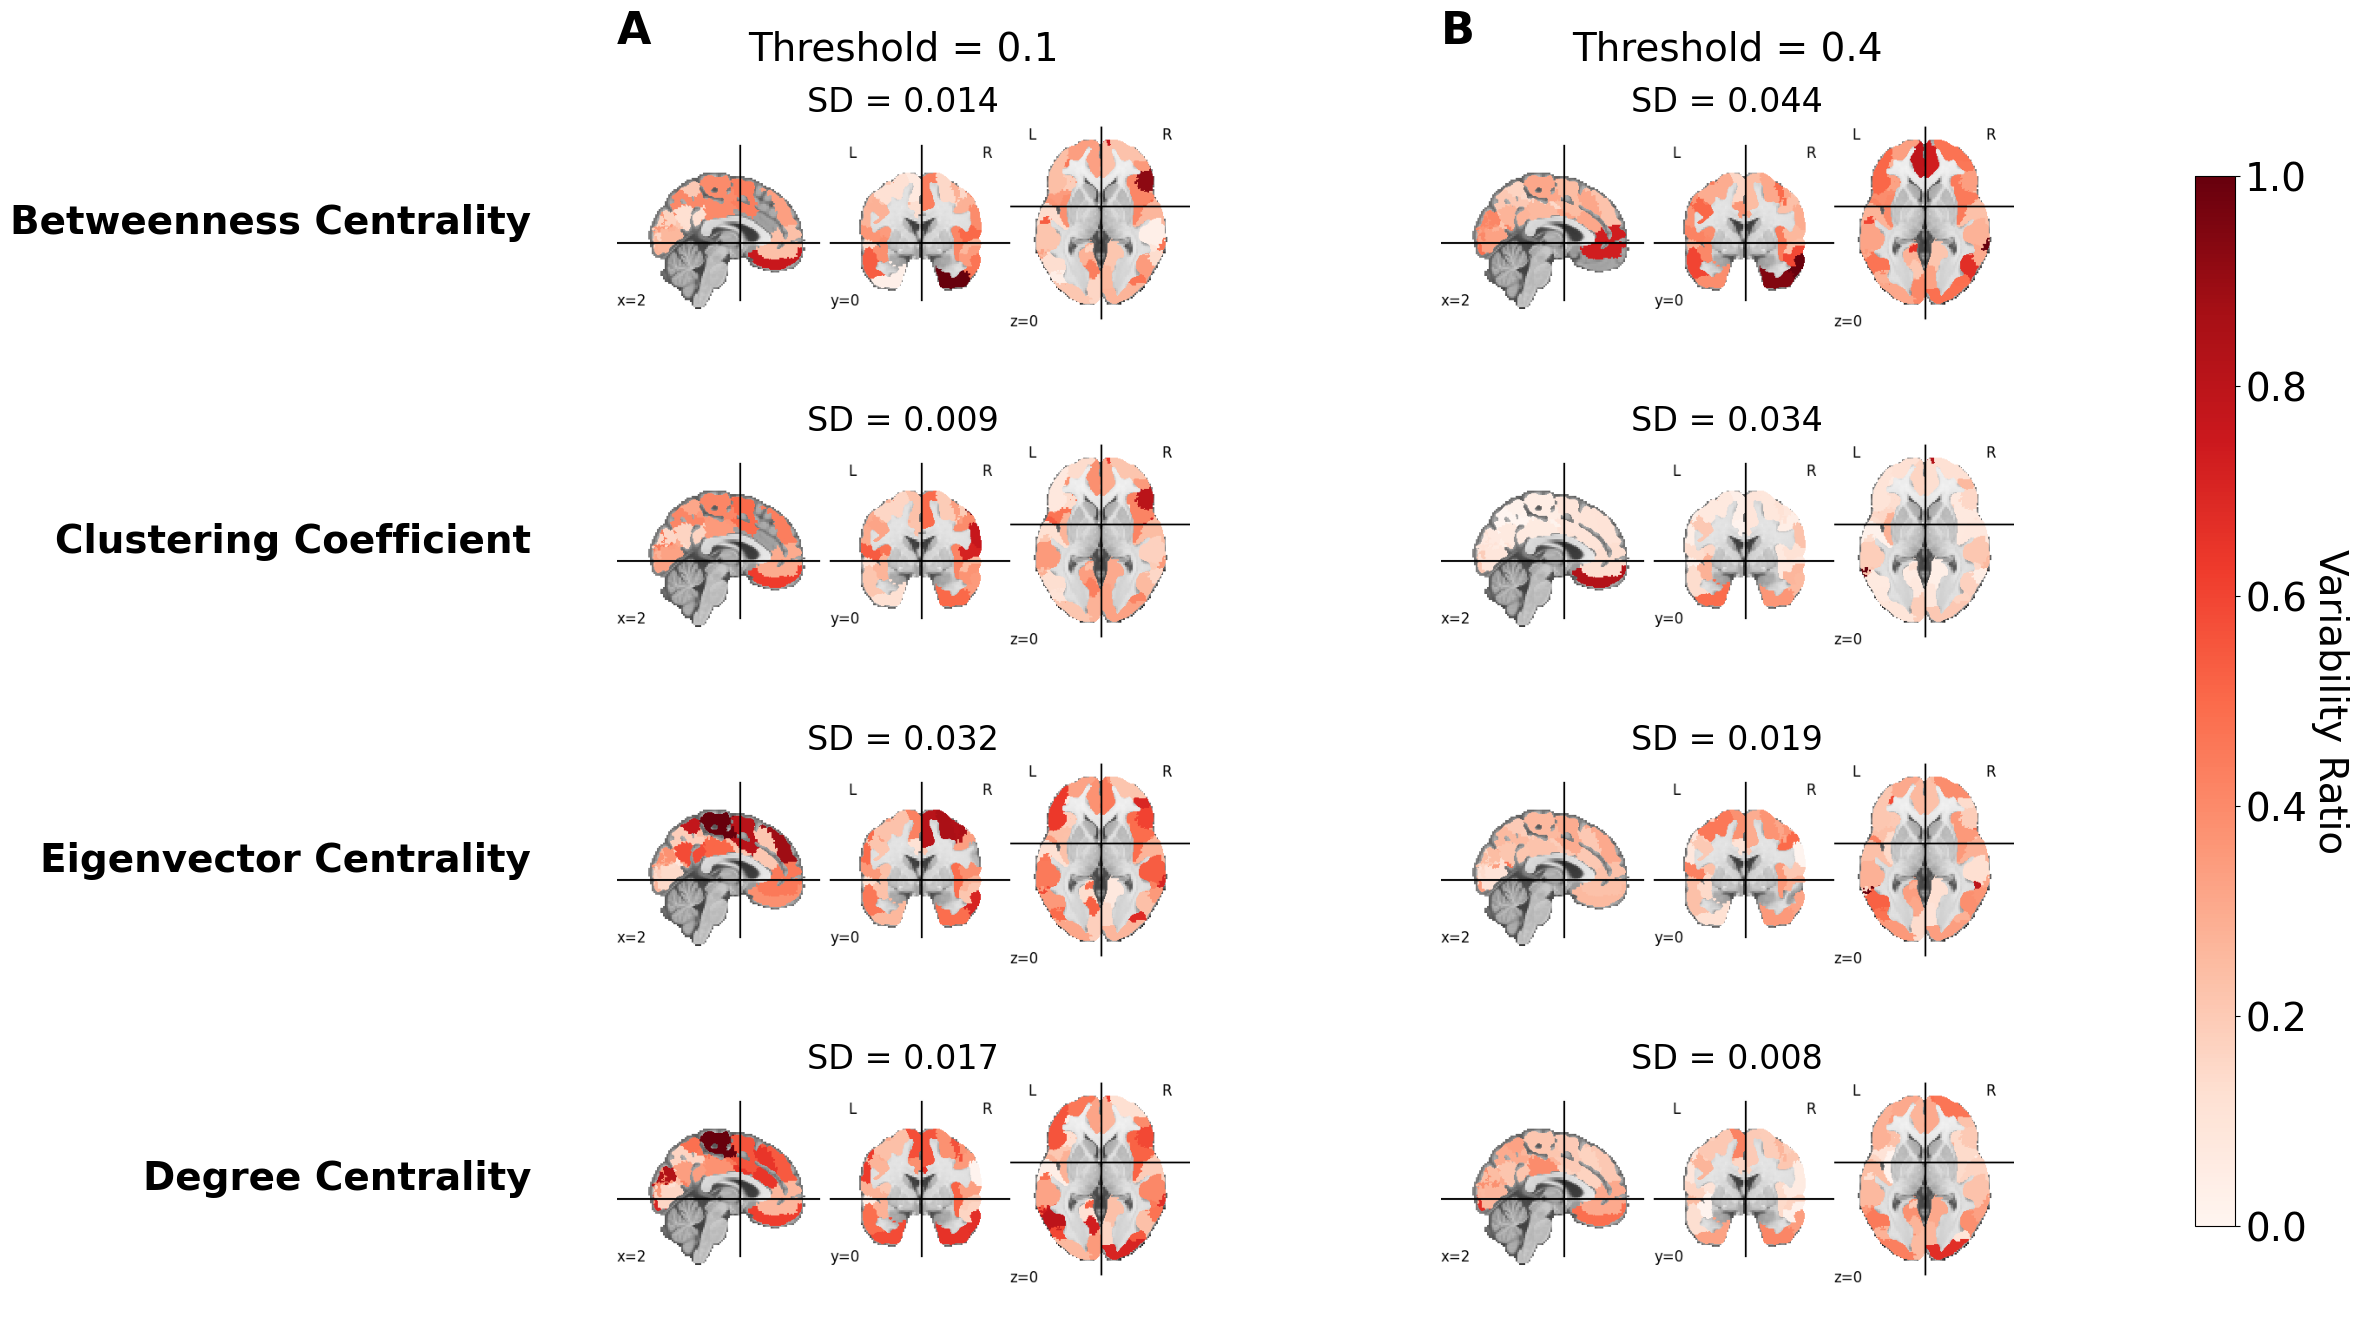

In [9]:
supplementary_pd, supplementary_pd_sd = plot_regional_npvr(
    "PD", group_npvr["pd"]
)
save_regional_figure(supplementary_pd, "fig4-PD")
plt.show()

supplementary_hc, supplementary_hc_sd = plot_regional_npvr(
    "HC", group_npvr["hc"]
)
save_regional_figure(supplementary_hc, "fig4-HC")
plt.show()

### Parkinson's disease

![Supplementary regional NPVR figure for PD](Figures/fig4-PD.png)

### Healthy controls

![Supplementary regional NPVR figure for HC](Figures/fig4-HC.png)

## Interpretation note

Colors encode each panel's normalized regional pattern and therefore should not be compared as absolute NPVR magnitudes across panels. The `SD` annotation retains the scale of the unnormalized regional NPVR values and summarizes regional dispersion within each metric, threshold, and population.